In [1]:
import math
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mdtraj as md
import numpy as np
import ot as pot
import seaborn as sns
import torch
import wandb

sys.path.insert(0, "..")
from src.data.preprocessing.tica import TicaModel, tica_features
from src.evaluation.metrics.distribution_distances import energy_distances
from src.evaluation.metrics.optimal_transport import torus_wasserstein, wasserstein
from src.evaluation.metrics.ramachandran import get_phi_psi_vectors
from src.models.utils import resample

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "svg.fonttype": "none",
})

PURPLE_PALETTE = sns.color_palette("BuPu", n_colors=10)

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────

# All 30 8AA test sequences (from configs/data/transferable/up_to_8aa.yaml)
SEQUENCES = [
    "ANKSMIEA", "CGSWHKQR", "CLCCGQWN", "DDRDTEQT", "DGVAHALS",
    "EKYYWMQT", "FWRVDHDM", "GNDLVTVI", "HWHSLICK", "IDHRQLKW",
    "IFGWVYTG", "ISKCKNGE", "KRRGFFLE", "MAPQTIAT", "MRDPVLFA",
    "MWNSTEMI", "MYGRNCYM", "NHQYGSDP", "NKEKFFQH", "NPCLCYML",
    "PGESTAES", "PLFHVMYV", "PPWRECNN", "PYIRNCVE", "SPHKMRLC",
    "SQQKVAFE", "VWIPVIDT", "WDLIQFRQ", "WTYAFAHS", "YFPHAGYT",
]

DATA_DIR="/home/mila/d/danyal.rehman/scratch/transferable-samplers/transferable-samplers/many-peptides-md"

# ── Paths (configure these for your machine) ─────────────────────────────────
# Directory containing PDB files: {PDB_DIR}/{SEQ}.pdb
PDB_DIR = Path(DATA_DIR + "/pdbs/test")

# Directory containing subsampled trajectories: {TRAJ_DIR}/{SEQ}_subsampled.npz
TRAJ_DIR = Path(DATA_DIR + "/trajectories_subsampled/test/8AA")

# Directory containing model samples in numbered subdirectories (60-89)
# Structure: {SAMPLES_BASE_DIR}/{folder_idx}/test/{SEQ}/samples.pt
# Each samples.pt file has keys: "prior_samples", "proposal_samples", "proposal_log_q"
# NOTE: Sample files are not needed when using cached metrics - these paths are placeholders
SAMPLES_BASE_DIRS = {
    "prose": Path(""),  # Not needed when using cached data
    "robin": Path(""),  # Not needed when using cached data
}

# Map sequences to their folder indices (60-89)
SEQUENCE_TO_FOLDER = {seq: idx for idx, seq in enumerate(SEQUENCES, start=60)}

# Cache path for computed metrics (avoids recomputation on subsequent runs)
CACHE_PATH = Path("data/scaling_metrics_cache.pkl")

# Normalization (matches configs/data/transferable/up_to_8aa.yaml)
POSITION_SCALE = 0.35

# Resampling (matches all configs: clip_reweighting_logits: 0.002)
CLIP_REWEIGHTING_LOGITS = 0.002

# Number of eval samples per metric computation (matches num_eval_samples in config)
NUM_EVAL_SAMPLES = 10_000

# Model names (corresponding to samples in SAMPLES_BASE_DIRS)
MODEL_NAMES = ["prose", "robin"]
# Model names (corresponding to {SEQ}_{model}_samples.pt files)

In [3]:
# ── Verify data availability ─────────────────────────────────────────────────
# Optionally download PDBs and trajectories from HuggingFace if not present.
# Uncomment the following lines if you need to download:
#
# from src.utils.huggingface import download_and_extract_pdb_tarfiles, download_evaluation_data
# download_and_extract_pdb_tarfiles(str(Path("../data")))
# download_evaluation_data(str(Path("../data")))

# Check that required files exist
missing_pdbs = [s for s in SEQUENCES if not (PDB_DIR / f"{s}.pdb").exists()]
missing_trajs = [s for s in SEQUENCES if not (TRAJ_DIR / f"{s}_subsampled.npz").exists()]

print(f"PDBs:         {len(SEQUENCES) - len(missing_pdbs)}/{len(SEQUENCES)} found in {PDB_DIR}")
print(f"Trajectories: {len(SEQUENCES) - len(missing_trajs)}/{len(SEQUENCES)} found in {TRAJ_DIR}")

# Skip sample file checks since we're using cached metrics
print(f"\nNote: Using cached metrics from {CACHE_PATH}")
print(f"      Sample files are not needed when cache exists.")

if missing_pdbs:
    print(f"\nMissing PDBs: {missing_pdbs[:5]}{'...' if len(missing_pdbs) > 5 else ''}")
if missing_trajs:
    print(f"Missing trajectories: {missing_trajs[:5]}{'...' if len(missing_trajs) > 5 else ''}")

PDBs:         30/30 found in /home/mila/d/danyal.rehman/scratch/transferable-samplers/transferable-samplers/many-peptides-md/pdbs/test
Trajectories: 30/30 found in /home/mila/d/danyal.rehman/scratch/transferable-samplers/transferable-samplers/many-peptides-md/trajectories_subsampled/test/8AA

Note: Using cached metrics from data/scaling_metrics_cache.pkl
      Sample files are not needed when cache exists.


In [4]:
# ── Helper functions ─────────────────────────────────────────────────────────

def get_samples_path(seq: str, model_name: str) -> Path:
    """Get the path to samples file for a sequence and model."""
    folder_idx = SEQUENCE_TO_FOLDER[seq]
    return SAMPLES_BASE_DIRS[model_name] / str(folder_idx) / "test" / f"{seq}" / "samples.pt"


def load_samples_dict(pt_path: Path) -> dict:
    """Load samples dictionary from .pt file."""
    d = torch.load(pt_path, map_location="cpu", weights_only=False)
    required = {"prior_samples", "proposal_samples", "proposal_log_q"}
    if not required.issubset(d):
        raise ValueError(f"{pt_path} missing keys {required - set(d)}")
    return d


def coerce_to_xyz(samples, n_atoms):
    """Convert samples to (N, n_atoms, 3) shape."""
    if isinstance(samples, torch.Tensor):
        samples = samples.cpu()
    else:
        samples = torch.as_tensor(samples)
    if samples.ndim == 2:
        samples = samples.reshape(-1, n_atoms, 3)
    return samples


def unnormalize(x, std=POSITION_SCALE):
    """Multiply by precomputed_std to get nm coordinates."""
    return x * std


def normalize(x, std=POSITION_SCALE):
    """Subtract CoM and divide by std."""
    x = x - x.mean(dim=1, keepdim=True)
    return x / std

ENERGY_DEVICE="cuda"

def setup_energy_fn(pdb, device=ENERGY_DEVICE):
    """
    Build the OpenMM energy function exactly as in transferable_peptide_datamodule.py:
    amber14-all.xml + implicit/obc1.xml, CutoffNonPeriodic 2nm, T=310K.
    Returns a function that takes NORMALIZED positions [B, n_atoms, 3]
    and returns energies in kT.
    """
    import openmm
    import openmm.app
    import openmm.unit
    from src.data.energy.openmm import OpenMMBridge
    from src.data.energy.energy import _BridgeEnergy as OpenMMEnergy

    forcefield = openmm.app.ForceField("amber14-all.xml", "implicit/obc1.xml")
    system = forcefield.createSystem(
        pdb.topology,
        nonbondedMethod=openmm.app.CutoffNonPeriodic,
        nonbondedCutoff=2.0 * openmm.unit.nanometer,
        constraints=None,
    )
    integrator = openmm.LangevinMiddleIntegrator(
        310 * openmm.unit.kelvin,
        0.3 / openmm.unit.picosecond,
        1.0 * openmm.unit.femtosecond,
    )
    platform_name = "CUDA" if device == "cuda" and torch.cuda.is_available() else "CPU"
    platform_name="CPU"
    potential = OpenMMEnergy(bridge=OpenMMBridge(system, integrator, platform_name=platform_name))

    def energy_fn(x_normalized):
        """Takes NORMALIZED samples [B, n_atoms, 3], returns energies [B] in kT."""
        x_unnorm = unnormalize(x_normalized)
        return potential.energy(x_unnorm).flatten()

    return energy_fn


def load_sequence_data(seq):
    """
    Load ground truth data, TICA model, topology, and PDB for a sequence.
    Mirrors prepare_eval() from transferable_peptide_datamodule.py.
    """
    import openmm.app

    # Load subsampled trajectory (ground truth)
    npz_path = TRAJ_DIR / f"{seq}_subsampled.npz"
    sub = np.load(npz_path)
    true_positions = torch.from_numpy(sub["positions"])  # unnormalized, nm
    true_samples_normalized = normalize(true_positions)  # normalized

    tica_model = TicaModel(
        projection=sub["tica_projection"],
        mean=sub["tica_mean"],
        dim=sub["tica_dim"],
    )

    # Load PDB and topology
    pdb_path = PDB_DIR / f"{seq}.pdb"
    pdb = openmm.app.PDBFile(str(pdb_path))
    topology = md.Topology.from_openmm(pdb.topology)
    n_atoms = topology.n_atoms

    # Build energy function
    energy_fn = setup_energy_fn(pdb)

    return {
        "true_samples_normalized": true_samples_normalized,
        "tica_model": tica_model,
        "topology": topology,
        "n_atoms": n_atoms,
        "energy_fn": energy_fn,
        "pdb": pdb,
    }

In [5]:
# ── Metric computation functions ────────────────────────────────────────────
# These exactly replicate the evaluation pipeline from the codebase.

def compute_resampled_metrics(
    proposal_samples_normalized,  # [N, n_atoms, 3] normalized
    proposal_log_q,               # [N]
    true_samples_normalized,      # [M, n_atoms, 3] normalized
    energy_fn,                    # normalized -> kT energies
    topology,                     # mdtraj topology
    tica_model,                   # TicaModel
    num_eval_samples=NUM_EVAL_SAMPLES,
    clip_logits=CLIP_REWEIGHTING_LOGITS,
):
    """
    Replicate the exact evaluation pipeline from
    transferable_boltzmann_generator_module.py (lines 536-557)
    + evaluate_peptide_data.py.

    Returns dict with energy_w2, torus_w2, tica_w2.
    """
    # 1. Compute energies on proposal samples
    proposal_energy = energy_fn(proposal_samples_normalized)  # [N] in kT

    # 2. Compute resampling logits: log p(x) - log q(x) = -E(x) - log q(x)
    resampling_logits = -proposal_energy - proposal_log_q

    # 3. Clip extreme logits (same as clip_reweighting_logits=0.002)
    if clip_logits:
        threshold = torch.quantile(resampling_logits, 1 - clip_logits)
        keep_mask = resampling_logits <= threshold
        proposal_samples_normalized = proposal_samples_normalized[keep_mask]
        proposal_energy = proposal_energy[keep_mask]
        resampling_logits = resampling_logits[keep_mask]

    # 4. Resample via multinomial (same as src/models/utils.py resample)
    _, resampling_index = resample(proposal_samples_normalized, resampling_logits, return_index=True)

    resampled_normalized = proposal_samples_normalized[resampling_index]
    resampled_energy = proposal_energy[resampling_index]

    # 5. Unnormalize for structural metrics
    resampled_unnorm = unnormalize(resampled_normalized)
    true_unnorm = unnormalize(true_samples_normalized)

    # 6. Slice to num_eval_samples (same as evaluate_peptide_data.py lines 30-35)
    n_eval = min(num_eval_samples, len(resampled_energy), len(true_samples_normalized))
    true_energy = energy_fn(true_samples_normalized[:n_eval])

    # ── Energy W2 ──
    e_metrics = energy_distances(
        resampled_energy[:n_eval],
        true_energy,
        prefix="resampled",
    )
    energy_w2 = e_metrics["resampled/energy_w2"]

    # ── Torus W2 (Ramachandran) ──
    # Uses unnormalized samples, same as ramachandran.py
    phis_true, psis_true = get_phi_psi_vectors(true_unnorm[:n_eval], topology)
    x_true = torch.cat([torch.from_numpy(phis_true), torch.from_numpy(psis_true)], dim=1)
    phis_pred, psis_pred = get_phi_psi_vectors(resampled_unnorm[:n_eval], topology)
    x_pred = torch.cat([torch.from_numpy(phis_pred), torch.from_numpy(psis_pred)], dim=1)
    torus_w2 = torus_wasserstein(x_true, x_pred)

    # ── TICA W2 ──
    # Uses unnormalized samples, same as tica_metric.py
    true_traj = md.Trajectory(true_unnorm[:n_eval].cpu().numpy(), topology=topology)
    pred_traj = md.Trajectory(resampled_unnorm[:n_eval].cpu().numpy(), topology=topology)
    features_true = tica_features(true_traj)
    features_pred = tica_features(pred_traj)
    n_tica = min(len(features_true), len(features_pred))
    tics_true = torch.Tensor(tica_model.transform(features_true))[:n_tica, 0:2]
    tics_pred = torch.Tensor(tica_model.transform(features_pred))[:n_tica, 0:2]
    # tica_metric.py calls distribution_distances which returns /tica/2-Wasserstein
    tica_w2 = wasserstein(tics_pred, tics_true, power=2)

    return {
        "energy_w2": energy_w2,
        "torus_w2": torus_w2,
        "tica_w2": tica_w2,
    }

In [6]:
# ── Compute metrics for all sequences (with caching) ────────────────────────

if CACHE_PATH.exists():
    print(f"Loading cached metrics from {CACHE_PATH}")
    with open(CACHE_PATH, "rb") as f:
        all_metrics = pickle.load(f)
    print(f"Loaded metrics for {len(all_metrics)} sequences.")
else:
    all_metrics = {}

# Process any sequences not yet in cache
sequences_to_process = []
for seq in SEQUENCES:
    for model_name in MODEL_NAMES:
        key = (seq, model_name)
        if key not in all_metrics:
            sequences_to_process.append(key)

if sequences_to_process:
    print(f"Need to compute metrics for {len(sequences_to_process)} (sequence, model) pairs.")
else:
    print("All metrics already cached.")
print(sequences_to_process)
# Group by sequence to avoid reloading sequence data
seqs_needing_compute = [s for s, _ in sequences_to_process]

for i, seq in enumerate(seqs_needing_compute):
    print(f"\n[{i+1}/{len(seqs_needing_compute)}] Processing {seq}...")

    seq_data = load_sequence_data(seq)
    n_atoms = seq_data["n_atoms"]

    for model_name in MODEL_NAMES:
        key = (seq, model_name)
        if key in all_metrics:
            continue

        pt_path = get_samples_path(seq, model_name)
        if not pt_path.exists():
            print(f"  WARNING: {pt_path} not found, skipping.")
            continue

        print(f"  Computing metrics for {model_name}...")
        samples_dict = load_samples_dict(pt_path)
        proposal_samples = coerce_to_xyz(samples_dict["proposal_samples"], n_atoms)
        proposal_log_q = samples_dict["proposal_log_q"].cpu()

        metrics = compute_resampled_metrics(
            proposal_samples_normalized=proposal_samples,
            proposal_log_q=proposal_log_q,
            true_samples_normalized=seq_data["true_samples_normalized"],
            energy_fn=seq_data["energy_fn"],
            topology=seq_data["topology"],
            tica_model=seq_data["tica_model"],
        )
        all_metrics[key] = metrics
        print(f"    energy_w2={metrics['energy_w2']:.4f}, torus_w2={metrics['torus_w2']:.4f}, tica_w2={metrics['tica_w2']:.4f}")

    # Save cache after each sequence (in case of interruption)
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE_PATH, "wb") as f:
        pickle.dump(all_metrics, f)

print(f"\nAll metrics computed and cached to {CACHE_PATH}.")

Loading cached metrics from data/scaling_metrics_cache.pkl
Loaded metrics for 60 sequences.
All metrics already cached.
[]

All metrics computed and cached to data/scaling_metrics_cache.pkl.


In [7]:
# ── Subsample and compute scaling curves ────────────────────────────────────
# For each subsample size, we draw a random subset of the 200k proposal samples,
# compute energies, resample, and measure the three metrics.
# The number of energy evaluations == the subsample size.

SUBSAMPLE_SIZES = [
    1000,
    2000,
    5000,
    10000,
    20000,
    50000,
    100000,
    200000,
    ]
SCALING_CACHE_PATH = Path("data/scaling_curves_cache.pkl")

if SCALING_CACHE_PATH.exists():
    print(f"Loading cached scaling curves from {SCALING_CACHE_PATH}")
    with open(SCALING_CACHE_PATH, "rb") as f:
        scaling_results = pickle.load(f)
    print(f"Loaded scaling results.")
else:
    scaling_results = {}  # key: (seq, model_name, n_samples) -> metrics dict

# Determine what needs computing
to_compute = []
for seq in SEQUENCES:
    for model_name in MODEL_NAMES:
        for n in SUBSAMPLE_SIZES:
            if (seq, model_name, n) not in scaling_results:
                to_compute.append((seq, model_name, n))

if to_compute:
    print(f"Need to compute {len(to_compute)} (seq, model, n) entries.")
else:
    print("All scaling curves already cached.")

# Group by sequence
seqs_needed = [s for s, _, _ in to_compute]

for i_seq, seq in enumerate(seqs_needed):
    print(f"\n[{i_seq+1}/{len(seqs_needed)}] {seq}")
    seq_data = load_sequence_data(seq)
    n_atoms = seq_data["n_atoms"]

    for model_name in MODEL_NAMES:
        # Check if any subsample sizes are needed for this (seq, model)
        sizes_needed = [n for s, m, n in to_compute if s == seq and m == model_name]
        if not sizes_needed:
            continue

        pt_path = get_samples_path(seq, model_name)
        if not pt_path.exists():
            print(f"  WARNING: {pt_path} not found, skipping.")
            continue

        print(f"  Loading {model_name} samples...")
        samples_dict = load_samples_dict(pt_path)
        all_proposal = coerce_to_xyz(samples_dict["proposal_samples"], n_atoms)
        all_log_q = samples_dict["proposal_log_q"].cpu()
        total_samples = len(all_proposal)

        for n in sorted(sizes_needed):
            if (seq, model_name, n) in scaling_results:
                continue
            if n > total_samples:
                print(f"    n={n} > total={total_samples}, skipping.")
                continue

            print(f"    n={n:>7d} energy evals...", end=" ")

            # Random subsample (deterministic seed per (seq, model, n))
            sub_proposal = all_proposal[:n]
            sub_log_q = all_log_q[:n]

            metrics = compute_resampled_metrics(
                proposal_samples_normalized=sub_proposal,
                proposal_log_q=sub_log_q,
                true_samples_normalized=seq_data["true_samples_normalized"],
                energy_fn=seq_data["energy_fn"],
                topology=seq_data["topology"],
                tica_model=seq_data["tica_model"],
            )
            scaling_results[(seq, model_name, n)] = metrics
            print(f"energy_w2={metrics['energy_w2']:.4f}, torus_w2={metrics['torus_w2']:.4f}, tica_w2={metrics['tica_w2']:.4f}")

    # Save after each sequence
    SCALING_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(SCALING_CACHE_PATH, "wb") as f:
        pickle.dump(scaling_results, f)

print(f"\nAll scaling curves computed and cached to {SCALING_CACHE_PATH}.")

Loading cached scaling curves from data/scaling_curves_cache.pkl
Loaded scaling results.
All scaling curves already cached.

All scaling curves computed and cached to data/scaling_curves_cache.pkl.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "data/training_losses.csv"
csv_path_val = "data/val_losses.csv"

use_train = True # if False, use val
loss = "train" if use_train else "val"

df = pd.read_csv(csv_path if use_train else csv_path_val)

In [10]:
NON_EMBED_PARAMS = {
    "xsmall": 1.46e6,
    "nominal": 7.36e6,
    "medium_large": 1.93e7,
    "large": 3.98e7,
}

COLUMNS = {
    "xsmall": {
        "loss": "autoregressive_chignolin_muon_scaling_xsmall_model_seed47_1000epochs - " + loss + "/loss",
        "step": "autoregressive_chignolin_muon_scaling_xsmall_model_seed47_1000epochs - _step",
        "label": "2M"
    },
    "nominal": {
        "loss": "autoregressive_chignolin_muon_scaling_nominal_model_seed47_1000epochs - " + loss + "/loss",
        "step": "autoregressive_chignolin_muon_scaling_nominal_model_seed47_1000epochs - _step",
        "label": "8M"
    },
    "medium_large": {
        "loss": "autoregressive_chignolin_muon_scaling_med_large_model_seed47_1000epochs - " + loss + "/loss",
        "step": "autoregressive_chignolin_muon_scaling_med_large_model_seed47_1000epochs - _step",
        "label": "20M"
    },
    "large": {
        "loss": "autoregressive_chignolin_muon_scaling_large_model_seed47_1000epochs - " + loss + "/loss",
        "step": "autoregressive_chignolin_muon_scaling_large_model_seed47_1000epochs - _step",
        "label": "45M"
    },
}

In [11]:
# ── Fetch scaling data from wandb ────────────────────────────────────────────

api = wandb.Api(timeout=120)

WANDB_PROJECT = "openproblems-comp/self-consume-bg"
SCALING_TAG = "scaling_3"

SCALING_RUN_NAMES = [
    "autoregressive_chignolin_small",
    "autoregressive_chignolin_nominal",
    "autoregressive_chignolin_medium",
    "autoregressive_chignolin_medium_large",
    "autoregressive_chignolin_large",
]

SCALING_MODEL_SIZES = ["8M", "15M", "45M", "80M", "126M"]

SCALING_PLOT = {
    "autoregressive_chignolin_small":        True,   # 8M
    "autoregressive_chignolin_nominal":      True,   # 15M
    "autoregressive_chignolin_medium":       True,   # 45M
    "autoregressive_chignolin_medium_large": True,   # 80M
    "autoregressive_chignolin_large":        True,   # 126M
}

SCALING_MAX_POINTS = {
    "autoregressive_chignolin_small":        1500,
    "autoregressive_chignolin_nominal":      1600,
    "autoregressive_chignolin_medium":       1200,
    "autoregressive_chignolin_medium_large": 1800,
    "autoregressive_chignolin_large":        None,
}

SCALING_X_AXIS = "flops"

SCALING_NON_EMBED_PARAMS = {
    "autoregressive_chignolin_small":        0.9 * 8e6,    # 7.2M
    "autoregressive_chignolin_nominal":      0.9 * 15e6,   # 13.5M
    "autoregressive_chignolin_medium":       0.9 * 45e6,   # 40.5M
    "autoregressive_chignolin_medium_large": 0.9 * 80e6,   # 72.0M
    "autoregressive_chignolin_large":        0.9 * 126e6,  # 113.4M
}

scaling_runs = api.runs(
    path=WANDB_PROJECT,
    filters={"tags": {"$in": [SCALING_TAG]}},
    per_page=200,
)

scaling_run_data = {}
for run in scaling_runs:
    name = getattr(run, "name", None)
    if name in SCALING_RUN_NAMES:
        rows = list(run.scan_history(keys=["train/loss", "_step"]))
        scaling_run_data[name] = pd.DataFrame(rows)
        print(f"Fetched {name}: {len(rows)} rows")

for rn in SCALING_RUN_NAMES:
    if rn not in scaling_run_data:
        print(f"WARNING: {rn} not found in wandb runs with tag '{SCALING_TAG}'")

scaling_selected = [
    (rn, sz) for rn, sz in zip(SCALING_RUN_NAMES, SCALING_MODEL_SIZES)
    if SCALING_PLOT.get(rn, False)
]

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Fetched autoregressive_chignolin_medium: 5860 rows
Fetched autoregressive_chignolin_medium_large: 3910 rows
Fetched autoregressive_chignolin_nominal: 7820 rows
Fetched autoregressive_chignolin_small: 7820 rows
Fetched autoregressive_chignolin_large: 4124 rows


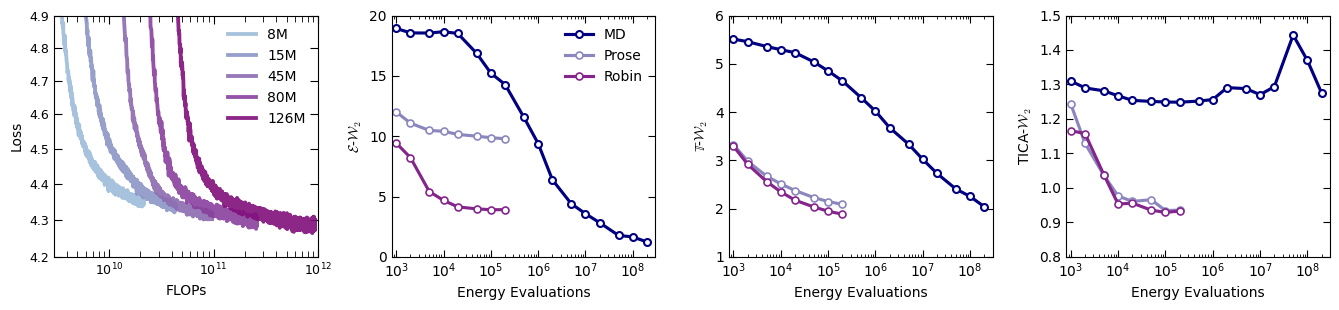

Figure saved to figures/scaling_plus_energy_metrics.pdf


In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import (
    FixedLocator,
    FuncFormatter,
    FormatStrFormatter,
    LogLocator,
    NullFormatter,
)

# ── Utilities ────────────────────────────────────────────────────────────────

def apply_in_ticks(ax):
    ax.tick_params(
        direction="in",
        which="major",
        length=5,
        top=True,
        right=True,
        left=True,
        bottom=True,
    )
    ax.tick_params(
        direction="in",
        which="minor",
        length=2,
        top=True,
        right=True,
        left=True,
        bottom=True,
    )

def apply_axis_limits(ax, limits):
    if limits is None:
        return
    if limits.get("xlim") is not None:
        ax.set_xlim(limits["xlim"])
    if limits.get("ylim") is not None:
        ax.set_ylim(limits["ylim"])

# ── Axis limits per subplot ──────────────────────────────────────────────────

AX_LIMITS = {
    0: {  # scaling plot
        "xlim": (3e9, 1e12),
        "ylim": (4.2, 4.9),
    },
    1: {  # energy_w2
        "xlim": (8e2, 3e8),
        "ylim": (0, 20),
    },
    2: {  # torus_w2
        "xlim": (8e2, 3e8),
        "ylim": (1, 6),
    },
    3: {  # tica_w2
        "xlim": (8e2, 3e8),
        "ylim": (0.8, 1.5),
    },
}

# ── Aggregate and plot with GPU hours ─────────────────────────────────────────

metric_names = ["energy_w2", "torus_w2", "tica_w2"]
metric_labels = [
    r"$\mathcal{E}$-$\mathcal{W}_2$",
    r"$\mathbb{T}$-$\mathcal{W}_2$",
    r"TICA-$\mathcal{W}_2$",
]

agg = {model: {m: [] for m in metric_names} for model in MODEL_NAMES}

for model_name in MODEL_NAMES:
    for n in SUBSAMPLE_SIZES:
        vals = {m: [] for m in metric_names}
        for seq in SEQUENCES:
            key = (seq, model_name, n)
            if key in scaling_results:
                for m in metric_names:
                    vals[m].append(scaling_results[key][m])
        for m in metric_names:
            if vals[m]:
                agg[model_name][m].append((n, np.mean(vals[m])))

# ── Load MD data ──────────────────────────────────────────────────────────────

md_csv_path = "data/mdlog_v1_proposal.csv"
md_df = pd.read_csv(md_csv_path, na_values=["", " ", "NaN"], keep_default_na=False)

md_df = md_df[md_df["data/test_sequences"].str.len() >= 8]
md_df = md_df.rename(
    columns=lambda c: c.replace("/resampled/", "/").replace("/proposal/", "/")
)

md_df = md_df.drop(columns=["data/test_sequences"])
md_mean = md_df.mean()

md_metric_map = {
    "energy_w2": "energy_w2",
    "torus_w2": "torus_wasserstein",
    "tica_w2": "tica/2-Wasserstein",
}

md_agg = {m: [] for m in metric_names}

for budget in [
    1_000,
    2_000,
    5_000,
    10_000,
    20_000,
    50_000,
    100_000,
    200_000,
    500_000,
    1_000_000,
    2_000_000,
    5_000_000,
    10_000_000,
    20_000_000,
    50_000_000,
    100_000_000,
    200_000_000,
]:
    for m_name in metric_names:
        col = f"test/mean/{budget}/{md_metric_map[m_name]}"
        if col in md_mean.index and not pd.isna(md_mean[col]):
            md_agg[m_name].append((budget, md_mean[col]))

# ── Plot styles ───────────────────────────────────────────────────────────────

model_colors = {
    "md": "navy",
    "prose": PURPLE_PALETTE[5],
    "robin": PURPLE_PALETTE[8],
}

model_display = {
    "md": "MD",
    "prose": "Prose",
    "robin": "Robin",
}

# ── Combined figure: 1 row × 4 columns ────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.2))

# ── (0) Scaling plot (from wandb) ────────────────────────────────────────────

scaling_palette = sns.color_palette("BuPu", n_colors=len(SCALING_RUN_NAMES) + 2)

ax = axes[0]

for run_name, label in scaling_selected:
    idx = SCALING_RUN_NAMES.index(run_name)
    if run_name not in scaling_run_data:
        print(f"Skipping {run_name} (not found)")
        continue
    sdf = scaling_run_data[run_name].dropna(subset=["train/loss", "_step"]).sort_values("_step")
    n = SCALING_MAX_POINTS.get(run_name)
    if n is not None:
        sdf = sdf.iloc[:n]
    steps = sdf["_step"]
    loss_vals = sdf["train/loss"]

    if SCALING_X_AXIS == "flops":
        x = SCALING_NON_EMBED_PARAMS[run_name] * steps
    else:
        x = steps

    ax.plot(
        x,
        loss_vals,
        label=label,
        color=scaling_palette[idx + 2],
        linewidth=2.75,
        alpha=0.9,
    )

ax.set_xscale("log")
ax.set_yscale("log")
apply_axis_limits(ax, AX_LIMITS.get(0))

ax.yaxis.set_major_locator(FixedLocator([4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9]))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax.yaxis.set_minor_formatter(NullFormatter())

ax.tick_params(
    which="major",
    direction="in",
    length=6,
    left=True,
    bottom=True,
    top=True,
    right=True,
    labelsize=9,
)
ax.tick_params(
    which="minor",
    direction="in",
    length=4,
    top=True,
    right=True,
    bottom=True,
    left=True,
)

ax.set_xlabel("FLOPs" if SCALING_X_AXIS == "flops" else "Step", fontsize=10)
ax.set_ylabel("Loss", fontsize=10)
ax.legend(frameon=False, fontsize=10)

# ── (1–3) Metrics vs Energy Evaluations ──────────────────────────────────────

for col, (m_name, m_label) in enumerate(zip(metric_names, metric_labels), start=1):
    ax = axes[col]

    if md_agg[m_name]:
        xs_md, ys_md = zip(*md_agg[m_name])
        ax.plot(
            xs_md,
            ys_md,
            "o-",
            color=model_colors["md"],
            markersize=5,
            linewidth=2.25,
            markerfacecolor="white",
            markeredgecolor=model_colors["md"],
            markeredgewidth=1.5,
            label=model_display["md"],
        )

    for model_name in MODEL_NAMES:
        data = agg[model_name][m_name]
        if not data:
            continue
        xs, ys = zip(*data)
        ax.plot(
            xs,
            ys,
            "o-",
            color=model_colors[model_name],
            markersize=5,
            linewidth=2.25,
            markerfacecolor="white",
            markeredgecolor=model_colors[model_name],
            markeredgewidth=1.2,
            label=model_display[model_name],
        )

    ax.set_xscale("log")
    ax.set_xlabel("Energy Evaluations", fontsize=10)
    ax.set_ylabel(m_label, fontsize=10)

    apply_axis_limits(ax, AX_LIMITS.get(col))

    # Fixed y-ticks for energy panel
    if m_name == "energy_w2":
        ax.yaxis.set_major_locator(FixedLocator([0, 5, 10, 15, 20]))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%d"))
    
    apply_in_ticks(ax)
    ax.tick_params(labelsize=10)
    if col == 1:
        ax.legend(frameon=False, fontsize=10)

# ── Save ─────────────────────────────────────────────────────────────────────

plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig(
    "figures/scaling_plus_energy_metrics.pdf",
    dpi=600,
    bbox_inches="tight",
)
plt.show()

print("Figure saved to figures/scaling_plus_energy_metrics.pdf")